In [1]:
import numpy as np
import matplotlib.pyplot as plt
import opt_einsum as oe
import scipy.sparse as sp
import time

from quant_rotor.core.dense.t_amplitudes_guess import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state

from quant_rotor.models.dense.support_ham import write_matrix_elements, m_to_p, basis_m_to_p_matrix_conversion
from quant_rotor.models.dense.density_matrix import density_matrix_1, density_matrix_trans

from quant_rotor.core.dense.hamiltonian import hamiltonian_dense
from quant_rotor.core.dense.hamiltonian_big import hamiltonian_general_dense, hamiltonian_big_dense
from quant_rotor.core.sparse.hamiltonian_big import hamiltonian_general_sparse, hamiltonian_big_sparse
from quant_rotor.core.sparse.hamiltonian import hamiltonian_sparse

from quant_rotor.core.dense.t_amplitudes_periodic_fast import t_periodic as t_periodic_fast_d
from quant_rotor.core.sparse.t_amplitudes_periodic_fast import t_periodic as t_periodic_fast_s
from quant_rotor.core.dense.t_amplitudes_periodic import t_periodic
from quant_rotor.core.dense.t_amplitudes_non_periodic import t_non_periodic

from quant_rotor.core.dense.de_solve_one_thermal import integration_scheme
from quant_rotor.core.dense.de_solve_one_thermal_dense import integration_scheme as integration_scheme_fast

np.set_printoptions(suppress = True, linewidth = 1500, threshold = np.inf, precision = 12)

# Graph 1

In [ ]:
site = 3
state = 9
state_NO = 5
final = 100

g = 0.2

In [15]:
def sites_CCC_func(site):

    _, energy, _, _ = integration_scheme(site, 11, g, t_init=0, t_final=100, nof_points=100000)

    return energy[-1].real

In [16]:
def sites_NO_func(site):

    H_NO, _, _ = hamiltonian_general_sparse(state, state_NO, site, g)
    print("Ham_Done")
    eig_val_NO, _ = sp.linalg.eigsh(H_NO, k=5, which='SA', tol=1e-19, maxiter=2000)

    return np.min(eig_val_NO)

In [17]:
def sites_ED_func(site):

    H, _, _ = hamiltonian_sparse(state, site, g)

    eig_val, _ = sp.linalg.eigsh(H, k=1, which='SA', tol=1e-19, maxiter=2000)

    return np.min(eig_val)

In [ ]:
n_CCC = 30
n_ED = 8
n_NO = 11

E_ED = np.zeros((n_ED))
E_NO = np.zeros((n_NO))
E_CCC = np.zeros((n_CCC))

sites_CCC = np.zeros((n_CCC))
sites_ED = np.zeros((n_ED))
sites_NO = np.zeros((n_NO))

In [8]:
for i in range(3, n_ED):

    E_ED[i - 3] = sites_ED_func(i)

    sites_ED[i-3] = i
    print(E_ED[i-3], sites_ED[i-3])

Finished site 0
Finished site 1
Finished site 2
-0.08587043888364759 3.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
-0.1051692655128193 4.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
-0.12772411036754058 5.0
Finished site 0
Finished site 1


/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_89375/961205076.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  E_ED[i - 3] = sites_ED_func(i)


Finished site 2
Finished site 3
Finished site 4
Finished site 5
-0.15218930200930866 6.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
Finished site 5
Finished site 6
-0.17715633332420402 7.0


In [ ]:
for i in range(3, n_CCC):

    E_CCC[i - 3] = sites_CCC_func(i)

    sites_CCC[i-3] = i
    print(E_CCC[i-3], sites_CCC[i-3])

-0.08793411470868667 3.0
-0.10783443349972918 4.0
-0.1306681226495107 5.0
-0.1555131175183597 6.0
-0.18091707548387057 7.0
-0.20656931131393955 8.0
-0.2323130022248852 9.0
-0.2580946139779799 10.0
-0.2838914328270877 11.0
-0.3096945528694664 12.0
-0.3355002785395787 13.0
-0.36130709406556544 14.0
-0.38711436689079326 15.0
-0.41292183265733934 16.0
-0.4387293800964248 17.0
-0.464536962226413 18.0
-0.4903445591308087 19.0
-0.5161521623428728 20.0
-0.5419597682535056 21.0
-0.5677673753208173 22.0
-0.5935749828847356 23.0
-0.6193825906621809 24.0
-0.645190198531564 25.0
-0.6709978064405776 26.0


In [ ]:
plt.plot(x_bigger_basis, np.log10(y_bigger_basis), label=f"#Basis size before truncation = {31}, NO = {state_NO}")
plt.plot((x), np.log10(y), label=f"#Basis size before truncation = {21}, NO = {state_NO}")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B /> 0")
plt.xlabel("Log10 of B")
plt.ylabel("log10 Energy percent diff")
plt.legend()
plt.show()

# Graph #2

In [54]:
def calculate_xy_no_field(site, state, state_NO, final, num):
    """Your calculation per frame. Modify this part only."""

    site_i = site

    g = 1
    D_val = 1 * 10**(-num)

    if site_i == 2:
        periodic = False
    else:
        periodic = True

    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    eig_val, eig_vec = np.linalg.eigh(H)

    int_1_2 = np.argsort(eig_val)

    psi_1 = eig_vec[:, int_1_2[0]]
    psi_2 = eig_vec[:, int_1_2[1]]

    pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

    D = density_matrix_1(state, site, pci_loc, 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

    print("ED done.")

    _, energy, _, _, _ = integration_scheme_fast(site_i, state_NO, 1, t_init=0, t_final=final, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

    E_CC = np.abs(energy[-1].real)
    E_ED = np.abs(np.min(eig_val_loc).real)

    per_diff = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200

    print(E_CC.real, E_ED.real)

    return (np.log10(D_val)).real, per_diff

In [55]:
site = 2
state = 21
state_NO = 5
final = 400

In [56]:
n = 6
x = np.zeros((n))
y = np.zeros((n))

for i in range(n):
    x[i], y[i] = calculate_xy_no_field(site, state, state_NO, final, i)
    print(x[i], y[i])

ED done.
0.3631883029431415 0.5129981196637204
0.0 34.19587723691478
ED done.
1.4184233538348412 1.41539738152528
-1.0 0.21356130765812908
ED done.
1.8101878039844657 1.809345151573959
-2.0 0.046561389044003546
ED done.
1.934365838630262 1.9343186584246572
-3.0 0.0024390826204983866
ED done.
1.958613621704378 1.9586130715959311
-4.0 2.8086628110443985e-05
ED done.
1.961371405493912 1.9613714017232793
-5.0 1.9224470633296127e-07


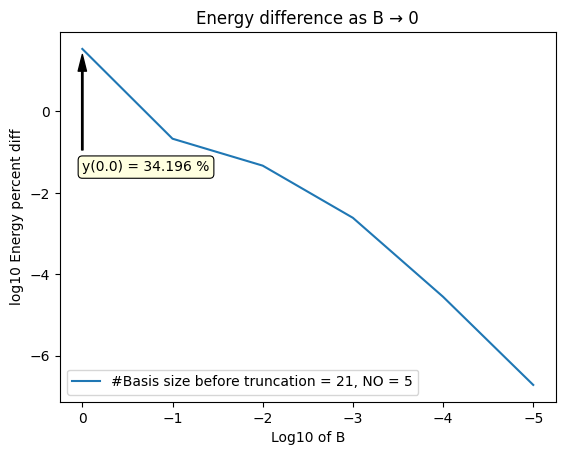

In [59]:
plt.plot((x), np.log10(y), label=f"#Basis size before truncation = {21}, NO = {state_NO}")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B → 0")
plt.xlabel("Log10 of B")
plt.ylabel("log10 Energy percent diff")
plt.legend()

x0 = x[0]
y0 = np.log10(y)[0]

plt.annotate(
    f"y({x[0]}) = {y[0]:.3f} %",
    xy=(x0, y0),                  # point to (x=0, y=y0)
    xytext=(0, y0 -3),      # position of text box
    textcoords='data',
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="black", lw=0.8),
    fontsize=10
)
plt.show()

In [50]:
y_bigger_basis

array([34.195877236915,  0.213561307658,  0.046561389044,  0.00243908262 ,  0.000028086628,  0.000000192245,  0.00000000775 ,  0.000000001046,  0.000000000107,  0.000000000011,  0.000000000001,  0.            ,  0.            ,  0.            ,  0.            ])

# Graph 3

In [2]:
def calculate_g(site, state, state_NO, final, num):
    """Your calculation per frame. Modify this part only."""

    site_i = 4

    g = 1
    D_val = num

    periodic = False

    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    periodic = True

    eig_val, eig_vec = np.linalg.eigh(H)

    int_1_2 = np.argsort(eig_val)

    psi_1 = eig_vec[:, int_1_2[0]]
    psi_2 = eig_vec[:, int_1_2[1]]

    pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

    D = density_matrix_1(state, site, pci_loc, 0)
    D_del = density_matrix_1(state, site, psi_1, 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    eig_val_D_del, matrix_p_to_NO_full_del = np.linalg.eigh(D_del)
    index_d_del = np.argsort(-eig_val_D_del)
    matrix_p_to_NO_del = matrix_p_to_NO_full_del[:, index_d_del[:state_NO]]

    K_NO_del = matrix_p_to_NO_del.T.conj() @ K @ matrix_p_to_NO_del
    matrix_p_to_NO_V_del = np.kron(matrix_p_to_NO_del, matrix_p_to_NO_del)
    V_NO_del = matrix_p_to_NO_V_del.conj().T @ V @ matrix_p_to_NO_V_del

    H_NO_del, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO_del, V_import=V_NO_del, Import_K_V=True, periodic=periodic)
    eig_val_del, eig_vec_del = np.linalg.eigh(H_NO_del)

    H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

    print("ED done.")

    time, energy, t_1_max, t_2_max, _ = integration_scheme_fast(site_i, state_NO, 1, t_init=0, t_final=final, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

    indecies = np.argsort(eig_val_loc)
    indecies_del = np.argsort(eig_val_del)

    E_CC = np.abs(energy[-1].real)
    E_ED = (np.abs(eig_val_loc[indecies[1]].real + eig_val_loc[indecies[0]].real)) / 2

    per_diff_1 = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200
    per_diff_2 = (np.abs(E_CC - np.abs(eig_val_loc[indecies[0]].real)) / (E_CC + np.abs(eig_val_loc[indecies[0]].real))) * 200

    print(per_diff_1, per_diff_2)

    return E_CC, E_ED, np.abs(eig_val_loc[indecies[0]].real), np.abs(eig_val_del[indecies_del[0]].real)

In [3]:
site = 2
state = 11
state_NO = state
final = 200

In [4]:
def calculate_xy_no_field(site, state, state_NO, final, num):
    """Your calculation per frame. Modify this part only."""

    site_i = 4

    g = 1
    D_val = num

    periodic = False

    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    periodic = True

    eig_val, eig_vec = np.linalg.eigh(H)

    int_1_2 = np.argsort(eig_val)

    psi_1 = eig_vec[:, int_1_2[0]]
    psi_2 = eig_vec[:, int_1_2[1]]

    pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

    D = density_matrix_1(state, site, pci_loc, 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

    print("ED done.")

    time, energy, t_1_max, t_2_max, _ = integration_scheme_fast(site_i, state_NO, 1, t_init=0, t_final=final, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

    indecies = np.argsort(eig_val_loc)

    print(eig_val_loc)

    E_CC = np.abs(energy[-1].real)
    E_ED = (np.abs(np.abs(eig_val_loc[indecies[1]].real) + np.abs(eig_val_loc[indecies[0]].real))) / 2

    per_diff_1 = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200
    per_diff_2 = (np.abs(E_CC - np.abs(eig_val_loc[indecies[0]].real)) / (E_CC + np.abs(eig_val_loc[indecies[0]].real))) * 200

    print(E_CC.real, E_ED, eig_val_loc[indecies[0]].real, eig_val_loc[indecies[1]].real)
    print((np.abs(eig_val_loc[indecies[1]].real + eig_val_loc[indecies[0]].real)))
    print((np.abs(eig_val_loc[indecies[1]].real + eig_val_loc[indecies[0]].real))/2)

    return (np.log10(D_val)).real, per_diff_1, per_diff_2

In [55]:
n = 20
x = np.zeros((n))
y_CC = np.zeros((n))
y_ED_avg = np.zeros((n))
y_ED_1 = np.zeros((n))
y_ED_deloc = np.zeros((n))

for i in range(10):

    # y_CC[i], y_ED_avg[i], y_ED_1[i], y_ED_deloc[i] = calculate_g(site, state, state_NO, final, i)
    # x[i] = i
    # print(x[i], y_CC[i], y_ED_avg[i], y_ED_1[i], y_ED_deloc[i])
    # print("\n")

    y_CC[i+10], y_ED_avg[i+10], y_ED_1[i+10], y_ED_deloc[i+10] = calculate_g(site, state, state_NO, final, 10 ** (-i-1))
    x[i+10] = 10 ** (-i)
    print(x[i+10], y_CC[i+10], y_ED_avg[i+10], y_ED_1[i+10], y_ED_deloc[i+10])
    print("\n\n")

ED done.
1.8550930502622829 0.0012637321600630685
0.0 7.478320127352387 7.340865287979733 7.478225622013053 7.477580325142509


ED done.


KeyboardInterrupt: 

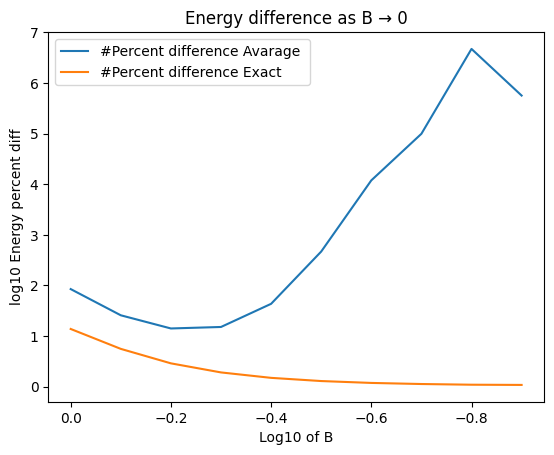

In [ ]:
plt.plot((x), y_CC, label=f"#Percent difference Avarage ")
plt.plot((x), y_ED_avg, label=f"#Percent difference Exact")
plt.plot((x), y_ED_1, label=f"#Percent difference Exact")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B → 0")
plt.xlabel("g")
plt.ylabel("log10 Energy percent diff")
plt.legend()

# x0 = x[0]
# y0 = np.log10(y_bigger_basis)[0]

# plt.annotate(
#     f"y({x_bigger_basis[0]}) = {y_bigger_basis[0]:.3f} %",
#     xy=(x0, y0),                  # point to (x=0, y=y0)
#     xytext=(0.3, y0 -8),      # position of text box
#     textcoords='data',
#     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
#     bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="black", lw=0.8),
#     fontsize=10
# )
plt.show()

In [ ]:
ED done.
3.01880110464208 2.9611214795142646
0.0 1.9291094262870985 1.141552538250456
ED done.
3.4910519466673677 3.4421156887845967
-0.1 1.4116565603445392 0.748486312087077
ED done.
3.9252252507500325 3.880282525936938
-0.2 1.1515644106415976 0.46279013167232685
ED done.
4.3218585956725875 4.271116953008014
-0.30000000000000004 1.1810028406833892 0.2834817608393899
ED done.
4.6834145712164394 4.607317133989989
-0.4000000000000001 1.6381365782806159 0.17627004745647856
ED done.
5.013410212419395 4.8812958431491245
-0.5 2.6704051343884005 0.1132373982333834
ED done.
5.315542647386033 5.103224069836809
-0.6 4.075695009050332 0.07614066411735608
ED done.
5.592487852231216 5.319923396313937
-0.7 4.995494574191686 0.05458173001496246
ED done.
5.864168155524752 5.48558203704107
-0.8 6.671267861589744 0.04089419535129039
ED done.
6.087940693884089 5.747638799512346
-0.9 5.750489776383348 0.03676022373808553

# Calculate times

In [2]:
g = 0.2

Change site

In [3]:
state = 11

In [4]:
site = 10

In [5]:
str_fast_d_site_1 = time.perf_counter()
_, _, _, _, _, n_iter_fast_d_site_1 = t_periodic_fast_d(site, state, g, True, Import=False)
end_fast_d_site_1 = time.perf_counter()

Done.


In [6]:
str_fast_s_site_1 = time.perf_counter()
_, _, _, _, _, n_iter_fast_s_site_1 = t_periodic_fast_s(site, state, g, True)
end_fast_s_site_1 = time.perf_counter()

Done.


/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [7]:
site = 100

In [8]:
str_fast_d_site_2 = time.perf_counter()
_, _, _, _, _, n_iter_fast_d_site_2 = t_periodic_fast_d(site, state, g, True, Import=False)
end_fast_d_site_2 = time.perf_counter()

Done.


In [9]:
str_fast_s_site_2 = time.perf_counter()
_, _, _, _, _, n_iter_fast_s_site_2 = t_periodic_fast_s(site, state, g, True)
end_fast_s_site_2 = time.perf_counter()

Done.


Change state

In [19]:
site = 3

In [20]:
state = 11

In [21]:
str_fast_d_state_1 = time.perf_counter()
_, _, _, _, _, n_iter_fast_d_state_1 = t_periodic_fast_d(site, state, g, True, Import=False)
end_fast_d_state_1 = time.perf_counter()

Done.


In [22]:
str_fast_s_state_1 = time.perf_counter()
_, _, _, _, _, n_iter_fast_s_state_1 = t_periodic_fast_s(site, state, g, True)
end_fast_s_state_1 = time.perf_counter()

Done.


/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [25]:
state = 151

In [26]:
str_fast_s_state_2 = time.perf_counter()
_, _, _, _, _, n_iter_fast_s_state_2 = t_periodic_fast_s(site, state, g, True)
end_fast_s_state_2 = time.perf_counter()

Done.


/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [27]:
str_fast_d_state_2 = time.perf_counter()
_, _, _, _, _, n_iter_fast_d_state_2 = t_periodic_fast_d(site, state, g, True, Import=False)
end_fast_d_state_2 = time.perf_counter()

Done.


In [28]:
print("State Dense: ")
print(f"Site 10: {(str_fast_d_site_1 - end_fast_d_site_1) / n_iter_fast_d_site_1}")
print(f"Site 100: {(str_fast_d_site_2 - end_fast_d_site_2) / n_iter_fast_d_site_2}")

print("\n")

print("State Sparse: ")
print(f"Site 10: {(str_fast_s_site_1 - end_fast_s_site_1) / n_iter_fast_s_site_1}")
print(f"Site 100: {(str_fast_s_site_2 - end_fast_s_site_2) / n_iter_fast_s_site_2}")

print("\n\n")

print("State Dense: ")
print(f"State 11: {(str_fast_d_state_1 - end_fast_d_state_1) / n_iter_fast_d_state_1}")
print(f"State 101: {(str_fast_d_state_2 - end_fast_d_state_2) / n_iter_fast_d_state_2}")

print("\n")

print("State Sparse: ")
print(f"State 11: {(str_fast_s_state_1 - end_fast_s_state_1) / n_iter_fast_s_state_1}")
print(f"state 101: {(str_fast_s_state_2 - end_fast_s_state_2) / n_iter_fast_s_state_2}")

State Dense: 
Site 10: -0.0023196973672479785
Site 100: -0.09212887444606933


State Sparse: 
Site 10: -0.07228789473638723
Site 100: -2.6106841118430326



State Dense: 
State 11: -0.0008952354158585271
State 101: -11.418306012294392


State Sparse: 
State 11: -0.017463309015147387
state 101: -5.850624644113552


## Non Linear

Change site

In [29]:
site = 5

In [30]:
state = 11

In [31]:
str_slow_np_state_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_state_1 = t_non_periodic(site, state, g)
end_slow_np_state_1 = time.perf_counter()

In [32]:
str_slow_p_state_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_state_1 = t_periodic(site, state, g)
end_slow_p_state_1 = time.perf_counter()

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [35]:
state = 15

In [36]:
str_slow_np_state_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_state_2 = t_non_periodic(site, state, g)
end_slow_np_state_2 = time.perf_counter()

In [37]:
str_slow_p_state_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_state_2 = t_periodic(site, state, g)
end_slow_p_state_2 = time.perf_counter()

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


Change state

In [38]:
state = 5

In [39]:
site = 11

In [40]:
str_slow_np_site_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_site_1 = t_non_periodic(site, state, g)
end_slow_np_site_1 = time.perf_counter()

In [41]:
str_slow_p_site_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_site_1 = t_periodic(site, state, g)
end_slow_p_site_1 = time.perf_counter()

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [46]:
site = 21

In [47]:
str_slow_np_site_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_site_2 = t_non_periodic(site, state, g)
end_slow_np_site_2 = time.perf_counter()

In [48]:
str_slow_p_site_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_site_2 = t_periodic(site, state, g)
end_slow_p_site_2 = time.perf_counter()

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [45]:
print("State Non-Linear: ")
print(f"Site 10: {(str_slow_np_site_1 - end_slow_np_site_1) / n_iter_slow_np_site_1}")
print(f"Site 100: {(str_slow_np_site_2 - end_slow_np_site_2) / n_iter_slow_np_site_2}")

print("\n")

print("State Linear: ")
print(f"Site 10: {(str_slow_p_site_1 - end_slow_p_site_1) / n_iter_slow_p_site_1}")
print(f"Site 100: {(str_slow_p_site_2 - end_slow_p_site_2) / n_iter_slow_p_site_2}")

print("\n\n")

print("State Non-Linear: ")
print(f"State 11: {(str_slow_np_state_1 - end_slow_np_state_1) / n_iter_slow_np_state_1}")
print(f"State 101: {(str_slow_np_state_2 - end_slow_np_state_2) / n_iter_slow_np_state_2}")

print("\n")

print("State Linear: ")
print(f"State 11: {(str_slow_p_state_1 - end_slow_p_state_1) / n_iter_slow_p_state_1}")
print(f"State 101: {(str_slow_p_state_2 - end_slow_p_state_2) / n_iter_slow_p_state_2}")

State Non-Linear: 
Site 10: -0.08192406874732114
Site 100: -0.2437511739495676


State Linear: 
Site 10: -0.015653620396430295
Site 100: -0.031536469882768065



State Non-Linear: 
State 11: -0.21281027054886192
State 101: -1.1986117497225905


State Linear: 
State 11: -0.0806438405594478
State 101: -0.4851236672264834
